# Classificador por Transfer Learning — Dataset ABC

Este notebook reproduz o notebook usado no vídeo **"3D Rendered Datasets in Blender for Beginners"**
(Adam Kelly, Immersive Limit), parte de treinamento do classificador.

Ele treina uma rede neural para classificar as imagens do dataset sintético (letras **A**, **B** e **C**)
gerado no Blender. Note que isto é um **classificador de imagem inteira** (diz se a imagem é A, B ou C),
diferente de um **detector de objetos** (que encontraria múltiplos objetos e caixas delimitadoras numa
mesma imagem).

Em vez de treinar uma CNN do zero, usamos **transfer learning**: partimos de um modelo já treinado no
ImageNet, disponível no TensorFlow Hub, e treinamos apenas a última camada para reconhecer as nossas
três classes. Isso é inspirado no tutorial oficial
[Transfer learning with TensorFlow Hub](https://www.tensorflow.org/hub/tutorials/tf2_image_retraining).

> **Como rodar:** abra esta pasta no VS Code, selecione o kernel Python do seu ambiente/venv e rode as
> células em ordem (`Shift+Enter`). Ou, pelo terminal: `jupyter notebook` ou `jupyter lab` dentro do
> ambiente virtual onde as dependências abaixo estão instaladas.

## Setup & Imports

Primeiro garantimos que o TensorFlow e o TensorFlow Hub estão instalados e importamos tudo que vamos usar.

**Ação necessária:** se você tiver uma GPU NVIDIA com CUDA configurado, pode instalar `tensorflow` normal
mesmo assim — a partir do TensorFlow 2.1 o pacote `tensorflow` já detecta e usa a GPU automaticamente
(o pacote separado `tensorflow-gpu` citado no vídeo foi descontinuado nas versões mais recentes).

In [1]:
# Instala as dependências (rode uma vez; pode comentar depois de instalado)
%pip install "tensorflow>=2.13.0"
%pip install "tensorflow_hub>=0.15.0"
%pip install matplotlib numpy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # hub.KerasLayer ainda usa a API do Keras 2 (tf_keras)

import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from pathlib import Path
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))



TensorFlow: 2.21.0
GPUs disponíveis: []


## Carregando os datasets de treino, validação e teste

Vamos carregar as imagens de treino, validação e teste em `ImageDataGenerator`s, que serão usados para
treinar e validar o modelo.

**Ação necessária:** ajuste `BASE_DIR` abaixo para apontar para a pasta onde o seu dataset sintético foi
renderizado. Funciona tanto com a saída do script do vídeo (`abc_dataset_video.py`, ex.: `C:/tmp/abc_test`)
quanto com a saída do gerador próprio (`gerador_dataset_sintetico.py`, ex.: `C:/tmp/dataset_abc`), já que
os dois organizam as imagens em subpastas `train/A`, `train/B`, `train/C`, `val/...` e `test/...`.

Uso `pathlib.Path` em vez de strings com barra invertida, para o caminho funcionar igual no Windows,
Linux e Mac sem precisar escapar nada.

In [3]:
# Define o tamanho de imagem e as pastas de treino, validação e teste
IMAGE_SHAPE = (224, 224)

# <<< AJUSTE AQUI para o caminho onde está o seu dataset renderizado >>>
BASE_DIR = Path("C:/tmp/abc_test")

train_dir = BASE_DIR / "train"
validation_dir = BASE_DIR / "val"
test_dir = BASE_DIR / "test"

for nome, caminho in [("train", train_dir), ("val", validation_dir), ("test", test_dir)]:
    if not caminho.exists():
        print(f"[aviso] pasta '{nome}' não encontrada em: {caminho}")


In [4]:
# Cria o gerador de imagens de treino
train_image_generator = ImageDataGenerator(rescale=1./255)
train_data_gen = train_image_generator.flow_from_directory(
    directory=str(train_dir), shuffle=True, target_size=IMAGE_SHAPE)


Found 900 images belonging to 3 classes.


In [5]:
# Cria o gerador de imagens de validação
validation_image_generator = ImageDataGenerator(rescale=1./255)
validation_data_gen = validation_image_generator.flow_from_directory(
    directory=str(validation_dir), shuffle=True, target_size=IMAGE_SHAPE)


Found 240 images belonging to 3 classes.


In [6]:
# Cria o gerador de imagens de teste
test_image_generator = ImageDataGenerator(rescale=1./255)
test_data_gen = test_image_generator.flow_from_directory(
    directory=str(test_dir), shuffle=True, target_size=IMAGE_SHAPE)


Found 30 images belonging to 3 classes.


## Exibindo algumas amostras

Vamos exibir algumas imagens de amostra dos datasets de treino, validação e teste, só para conferir que
os geradores estão carregando tudo certinho antes de partir para o treino.

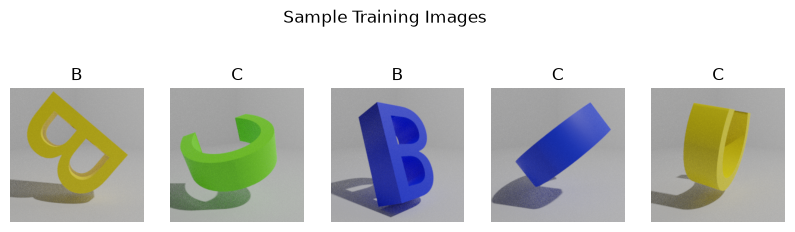

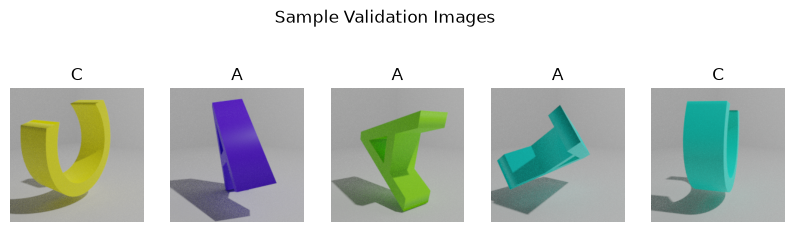

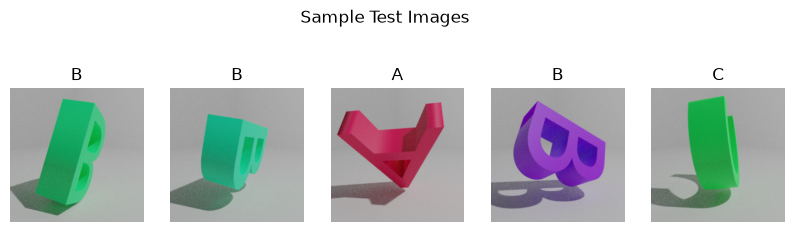

In [7]:
def display_samples(data_gen, title):
    # Monta um dicionário de consulta para os índices de classe
    classes = dict()
    for key, val in data_gen.class_indices.items():
        classes[val] = key

    # Pega algumas imagens e rótulos de amostra
    sample_images, sample_labels = next(data_gen)

    # Plota as imagens e os rótulos
    plt.figure(figsize=(10, 3))
    plt.subplots_adjust(hspace=0.5)
    for n in range(min(5, len(sample_images))):
        plt.subplot(1, 5, n + 1)
        plt.imshow(sample_images[n])
        plt.title(classes[np.argmax(sample_labels[n])])
        plt.axis('off')
    _ = plt.suptitle(title)

display_samples(train_data_gen, 'Sample Training Images')
display_samples(validation_data_gen, 'Sample Validation Images')
display_samples(test_data_gen, 'Sample Test Images')


## Criando o modelo

Agora vamos criar um modelo do TensorFlow baseado no `imagenet/mobilenet_v2_100_224/feature_vector`, um
modelo pré-treinado que nunca viu essas letras 3D antes — vamos treinar (retreinar) só a camada final
para as nossas três classes.

Fonte do modelo base: https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4

In [8]:
# Cria um modelo do TensorFlow para classificar as imagens
num_classes = len(train_data_gen.class_indices)

model = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4",
                    trainable=False, input_shape=IMAGE_SHAPE + (3,)),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Mostra o resumo do modelo
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 2261827 (8.63 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


## Compilando o modelo

> **Nota técnica:** o vídeo original usa `Dense(..., activation='softmax')` junto com
> `CategoricalCrossentropy(from_logits=True)`. Tecnicamente essas duas opções não deveriam ser combinadas
> (`from_logits=True` espera valores brutos, não uma saída já passada por softmax), mas na prática o
> treino ainda funciona porque a ordem relativa das probabilidades — usada no `argmax` da previsão — se
> mantém. Deixei fiel ao vídeo abaixo; se quiser a versão tecnicamente "correta", troque para
> `from_logits=False` (já que a última camada já aplica softmax).

In [9]:
# Compila o modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)


## Treinamento

No bloco abaixo vamos treinar a rede neural. No vídeo original, o autor relata de 93% a 95% de acurácia
no conjunto de validação depois de 4 épocas.

In [10]:
# Calcula os passos por época de treino e validação
train_steps_per_epoch = np.ceil(train_data_gen.samples / train_data_gen.batch_size)
val_steps_per_epoch = np.ceil(validation_data_gen.samples / validation_data_gen.batch_size)

# Treina o modelo
epochs = 20
history = model.fit(train_data_gen,
                     epochs=epochs,
                     steps_per_epoch=train_steps_per_epoch,
                     validation_data=validation_data_gen,
                     validation_steps=val_steps_per_epoch)


Epoch 1/20


c:\tmp\.venv\Lib\site-packages\tf_keras\src\backend.py:5577: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


29/29 [==============================] - 35s 1s/step - loss: 0.6772 - acc: 0.7178 - val_loss: 0.3783 - val_acc: 0.8917
Epoch 2/20
29/29 [==============================] - 28s 966ms/step - loss: 0.2507 - acc: 0.9344 - val_loss: 0.2758 - val_acc: 0.9042
Epoch 3/20
29/29 [==============================] - 28s 987ms/step - loss: 0.1727 - acc: 0.9600 - val_loss: 0.2429 - val_acc: 0.9167
Epoch 4/20
29/29 [==============================] - 30s 1s/step - loss: 0.1360 - acc: 0.9711 - val_loss: 0.2302 - val_acc: 0.9250
Epoch 5/20
29/29 [==============================] - 29s 1s/step - loss: 0.1149 - acc: 0.9756 - val_loss: 0.2351 - val_acc: 0.9125
Epoch 6/20
29/29 [==============================] - 30s 1s/step - loss: 0.0978 - acc: 0.9778 - val_loss: 0.2033 - val_acc: 0.9292
Epoch 7/20
29/29 [==============================] - 31s 1s/step - loss: 0.0874 - acc: 0.9789 - val_loss: 0.1950 - val_acc: 0.9333
Epoch 8/20
29/29 [==============================] - 31s 1s/step - loss: 0.0797 - acc: 0.9822 - 

### Gráfico de acurácia e perda (adição própria)

O vídeo não plota isso, mas ajuda bastante a visualizar se o modelo está convergindo bem ou se está
sofrendo overfitting entre as épocas de treino e validação.

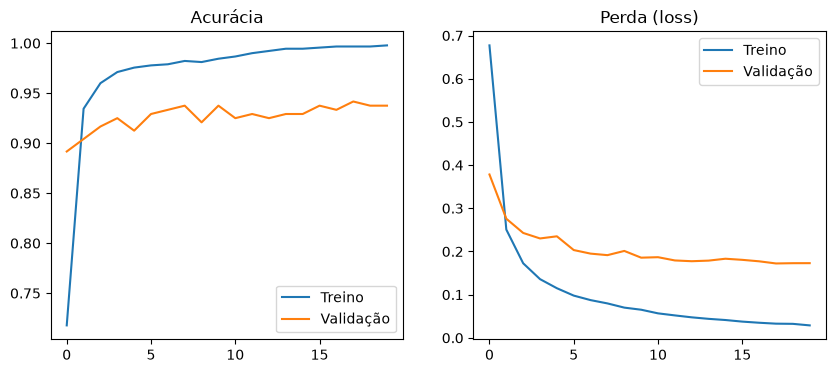

In [11]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino')
plt.plot(epochs_range, val_acc, label='Validação')
plt.legend(loc='lower right')
plt.title('Acurácia')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino')
plt.plot(epochs_range, val_loss, label='Validação')
plt.legend(loc='upper right')
plt.title('Perda (loss)')

plt.show()


## Inferência

Agora vamos pegar o modelo treinado e rodar algumas imagens de teste que ele nunca viu, para ver como
ele se sai.

In [12]:
# Monta um array numpy de consulta para os nomes das classes
class_names = np.empty([len(test_data_gen.class_indices)], dtype=object, order='C')
for key, val in test_data_gen.class_indices.items():
    class_names[val] = key

# Pega um lote de imagens e rótulos de teste
test_data_gen.reset()
image_batch, label_batch = next(test_data_gen)

# Prediz a classe de cada imagem usando o nosso modelo
predicted_batch = model.predict(image_batch)
predicted_id = np.argmax(predicted_batch, axis=-1)
predicted_label_batch = class_names[predicted_id]
label_id = np.argmax(label_batch, axis=-1)


1/1 [==============================] - 1s 1s/step


## Mostrando as previsões

Vamos exibir as previsões para as primeiras 30 imagens de teste. Se o treino funcionou direito, a
maioria deve estar correta (título em verde), e as que erraram (título em vermelho) devem ser casos
razoavelmente difíceis, como ângulos ou cores que deixam a letra ambígua.

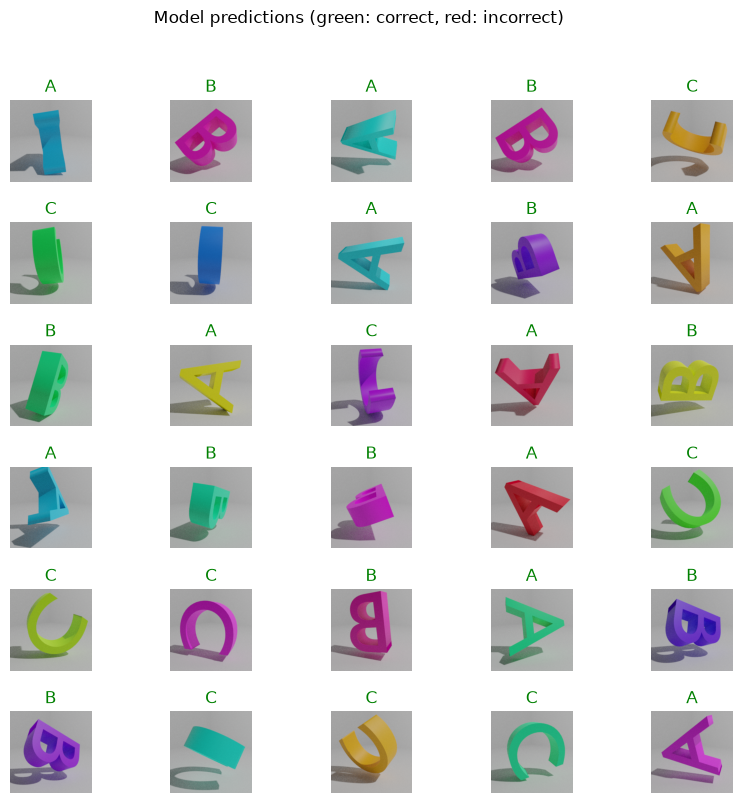

In [13]:
plt.figure(figsize=(10, 9))
plt.subplots_adjust(hspace=0.5)
for n in range(min(30, len(image_batch))):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n])
    color = "green" if predicted_id[n] == label_id[n] else "red"
    plt.title(predicted_label_batch[n].title(), color=color)
    plt.axis('off')
_ = plt.suptitle("Model predictions (green: correct, red: incorrect)")


## Salvando o modelo (adição própria)

Só para não perder o resultado do treino: salva o modelo treinado em disco, no formato nativo do Keras,
para poder recarregar depois sem precisar treinar tudo de novo.

In [14]:
model.save("classificador_abc.keras")
print("Modelo salvo em classificador_abc.keras")


Modelo salvo em classificador_abc.keras
